# BÀI TẬP TUẦN 4: WEB SCRAPING - THU THẬP & LÀM SẠCH DỮ LIỆU THƯƠNG MẠI ĐIỆN TỬ
### Giảng viên: Bùi Anh Tuấn | Khóa học: Phân tích Dữ liệu với Python
---
### Mục tiêu bài tập (Theo mục 10 - Slide Week 4):
1. **Thu thập danh sách sản phẩm từ một trang thương mại điện tử**: Áp dụng thư viện 
equests và BeautifulSoup để trích xuất dữ liệu đa trang (tên sách, giá tiền, đánh giá sao, tình trạng kho, đường link).
2. **Lưu dữ liệu vào CSV và làm sạch dữ liệu trước khi phân tích**: Chuẩn hóa kiểu dữ liệu số, loại bỏ ký tự tiền tệ, mã hóa nhãn đánh giá và trực quan hóa phân phối bằng pandas, matplotlib, seaborn.
3. **So sánh hai phương pháp Web Scraping: BeautifulSoup vs Scrapy**: Phân tích kiến trúc, hiệu năng, trường hợp sử dụng và cung cấp mã nguồn đối chiếu.


### Step 1. Khai báo các thư viện cần thiết

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Thiết lập phong cách đồ họa
sns.set_theme(style='whitegrid')
%matplotlib inline
print('Import thư viện thành công!')

Import thư viện thành công!


### Step 2. Phân tích cấu trúc HTML của 1 trang mẫu (Trang 1)
*Trang web thực hành: Books to Scrape (http://books.toscrape.com)*

In [2]:
sample_url = 'http://books.toscrape.com/catalogue/page-1.html'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

res = requests.get(sample_url, headers=headers)
print('HTTP Status Code:', res.status_code)

soup = BeautifulSoup(res.text, 'html.parser')
# Tìm cuốn sách đầu tiên trên trang
first_book = soup.find('article', class_='product_pod')

title = first_book.h3.a.get('title')
price = first_book.find('p', class_='price_color').text.strip()
rating_class = [c for c in first_book.find('p', class_='star-rating')['class'] if c != 'star-rating'][0]
stock = first_book.find('p', class_='instock availability').text.strip()

print(f'Tên sách: {title}')
print(f'Giá thô: {price}')
print(f'Xếp hạng sao: {rating_class}')
print(f'Trạng thái kho: {stock}')

HTTP Status Code: 200
Tên sách: A Light in the Attic
Giá thô: Â£51.77
Xếp hạng sao: Three
Trạng thái kho: In stock


### Step 3. Thu thập dữ liệu sản phẩm qua 5 trang (Multi-page Crawling)
*Thu thập 100 sản phẩm với độ trễ lịch sự 0.5s giữa các request (Polite Scraping)*

In [3]:
base_url = 'http://books.toscrape.com/catalogue/page-{}.html'
products_list = []
total_pages = 5

for page in range(1, total_pages + 1):
    url = base_url.format(page)
    r = requests.get(url, headers=headers)
    if r.status_code != 200:
        continue
    
    r.encoding = 'utf-8'
    page_soup = BeautifulSoup(r.text, 'html.parser')
    cards = page_soup.find_all('article', class_='product_pod')
    
    for c in cards:
        t = c.h3.a.get('title', '').strip()
        p = c.find('p', class_='price_color').text.strip()
        rc = c.find('p', class_='star-rating').get('class', [])
        r_str = [x for x in rc if x != 'star-rating'][0] if len(rc) > 1 else 'Unknown'
        st = c.find('p', class_='instock availability').text.strip()
        rel_link = c.h3.a.get('href', '')
        full_link = 'http://books.toscrape.com/catalogue/' + rel_link
        
        products_list.append({
            'title': t,
            'price_raw': p,
            'rating_str': r_str,
            'availability_raw': st,
            'url': full_link
        })
    time.sleep(0.5)

df_raw = pd.DataFrame(products_list)
print(f'Thu thập thành công {len(df_raw)} sản phẩm!')
df_raw.head()

Thu thập thành công 100 sản phẩm!


,title,price_raw,rating_str,availability_raw,url
0,A Light in the Attic,£51.77,Three,In stock,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,£53.74,One,In stock,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,£50.10,One,In stock,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,£47.82,Four,In stock,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,£54.23,Five,In stock,http://books.toscrape.com/catalogue/sapiens-a-...


### Step 4. Lưu dữ liệu thô vào file CSV (products_raw.csv)

In [4]:
df_raw.to_csv('products_raw.csv', index=False, encoding='utf-8-sig')
print('Đã lưu file products_raw.csv thành công!')

Đã lưu file products_raw.csv thành công!


### Step 5. Làm sạch dữ liệu (Data Cleaning) trước khi phân tích
1. Loại bỏ ký tự tiền tệ (£), chuyển giá sang kiểu loat.
2. Ánh xạ xếp hạng sao chữ (One, Two, Three, Four, Five) sang số nguyên 1, 2, 3, 4, 5.
3. Chuẩn hóa trạng thái kho thành biến Boolean is_in_stock.


In [5]:
df_clean = df_raw.copy()

# 1. Trích xuất số thực cho giá tiền
df_clean['price_gbp'] = df_clean['price_raw'].str.extract(r'(\d+\.\d+)')[0].astype(float)

# 2. Chuyển đổi xếp hạng sao sang dạng số
rating_dict = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df_clean['rating_stars'] = df_clean['rating_str'].map(rating_dict).fillna(0).astype(int)

# 3. Chuẩn hóa tình trạng kho
df_clean['is_in_stock'] = df_clean['availability_raw'].str.contains('In stock', case=False)

# Giữ lại các cột đã làm sạch
df_clean = df_clean[['title', 'price_gbp', 'rating_stars', 'is_in_stock', 'url']]

# Lưu ra file CSV sạch
df_clean.to_csv('products_cleaned.csv', index=False, encoding='utf-8-sig')
print('Đã lưu file products_cleaned.csv thành công!')
df_clean.head()

Đã lưu file products_cleaned.csv thành công!


,title,price_gbp,rating_stars,is_in_stock,url
0,A Light in the Attic,51.77,3,True,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,53.74,1,True,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,50.10,1,True,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,47.82,4,True,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,54.23,5,True,http://books.toscrape.com/catalogue/sapiens-a-...


### Step 6. Phân tích thống kê & Trực quan hóa dữ liệu (EDA)

        price_gbp  rating_stars
count  100.000000    100.000000
mean    34.560700      2.930000
std     14.638531      1.423149
min     10.160000      1.000000
25%     19.897500      2.000000
50%     34.775000      3.000000
75%     47.967500      4.000000
max     58.110000      5.000000


C:\Users\pc\AppData\Local\Temp\ipykernel_16700\1969947686.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=axes[1], palette='viridis')


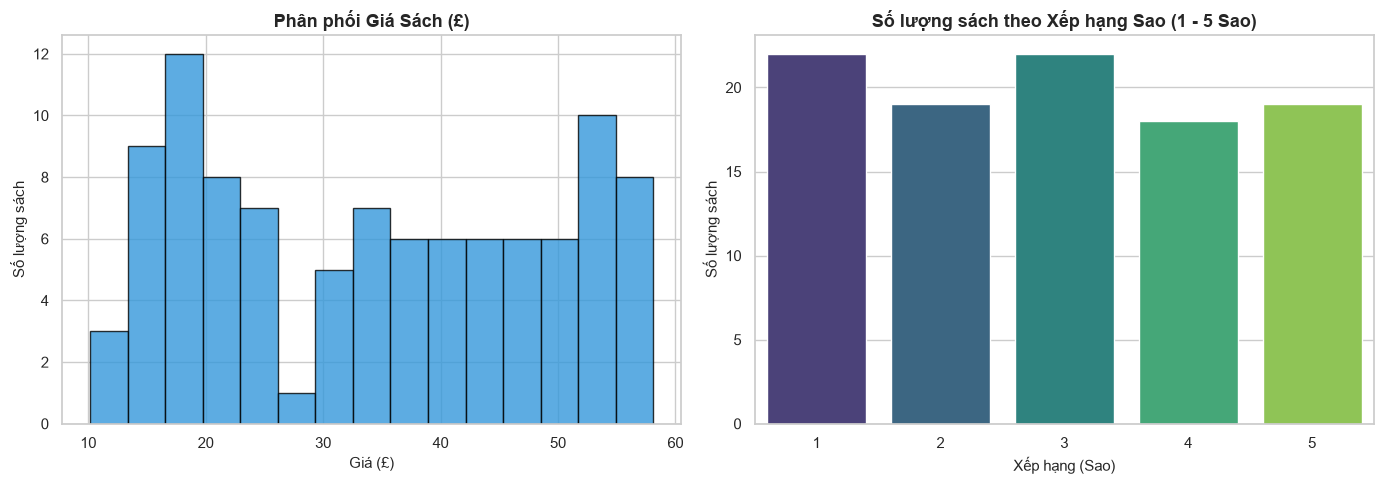

In [6]:
# Bảng thống kê mô tả
stats = df_clean[['price_gbp', 'rating_stars']].describe()
print(stats)

# Vẽ biểu đồ phân phối giá sách và xếp hạng sao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram phân phối giá
axes[0].hist(df_clean['price_gbp'], bins=15, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Phân phối Giá Sách (£)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Giá (£)', fontsize=11)
axes[0].set_ylabel('Số lượng sách', fontsize=11)

# 2. Bar chart xếp hạng sao
rating_counts = df_clean['rating_stars'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Số lượng sách theo Xếp hạng Sao (1 - 5 Sao)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Xếp hạng (Sao)', fontsize=11)
axes[1].set_ylabel('Số lượng sách', fontsize=11)

plt.tight_layout()
plt.show()

### Step 7. So sánh hai phương pháp Web Scraping: BeautifulSoup vs Scrapy

| Tiêu chí | BeautifulSoup (bs4) | Scrapy Framework |
| :--- | :--- | :--- |
| **Bản chất** | Là một thư viện bóc tách cú pháp HTML/XML (Parser library). Cần kết hợp với thư viện 
equests để tải trang web. | Là một khung ứng dụng thu thập dữ liệu web hoàn chỉnh (Full-featured Crawling Framework). |
| **Hiệu năng & Tốc độ** | Chạy tuần tự, đơn luồng (Synchronous). Mỗi trang phải chờ tải xong mới tới trang tiếp theo, tốc độ chậm khi cào quy mô lớn. | Chạy bất đồng bộ (Asynchronous) dựa trên Twisted engine. Cho phép gửi hàng trăm request đồng thời, tốc độ cực nhanh. |
| **Cấu trúc & Độ phức tạp** | Rất đơn giản, linh hoạt, viết trong 1 file script nhỏ gọn hoặc trong Jupyter Notebook. Rất phù hợp cho người mới học. | Có cấu trúc dự án chuẩn chỉ (Spiders, Items, Pipelines, Middlewares, Settings). Đòi hỏi thời gian làm quen và học tập nhiều hơn. |
| **Xử lý phân trang & link** | Phải tự viết vòng lặp or page in range(...) hoặc tự tìm thẻ <a> để lấy URL và gửi tiếp request. | Tự động hóa hoàn toàn với 
esponse.follow() hoặc CrawlSpider (LinkExtractor). Quản lý hàng đợi (Request Queue) thông minh. |
| **Xuất dữ liệu** | Phải tự viết code lưu file (như df.to_csv() hoặc thư viện csv). | Tích hợp sẵn cơ chế Feed Exports: chỉ cần thêm cờ -o data.csv hoặc -o data.json khi chạy lệnh. |
| **Tính năng tích hợp** | Không có sẵn; phải tự cài thêm thư viện quản lý proxy, xoay User-Agent, xử lý robots.txt. | Tích hợp sẵn cơ chế chống chặn (AutoThrottle, User-Agent rotation, Proxy Middleware, tuân thủ ROBOTSTXT_OBEY = True). |
| **Trường hợp khuyên dùng** | Bài toán nhỏ, vừa, phân tích dữ liệu nhanh trong Jupyter Notebook, nghiên cứu học tập hoặc dự án ít hơn 10.000 trang. | Dự án thu thập dữ liệu quy mô lớn (hàng trăm nghìn/hàng triệu trang), crawl định kỳ hàng ngày, hệ thống dữ liệu doanh nghiệp lớn. |
